In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import seaborn as sns

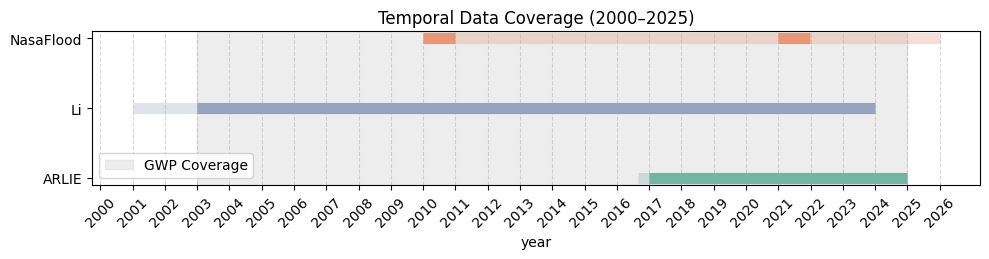

In [2]:

# Daten
data = [
    ("GWP",       "01.01.2003", "31.12.2024", None, None),
    ("ARLIE",     "01.09.2016", "31.12.2024", "01.01.2017", "31.12.2024"),
    ("Li",        "01.01.2001", "31.12.2023", "01.01.2003", "31.12.2023"),
    ("NasaFlood", "01.01.2010", "31.12.2025", "01.01.2010", "31.12.2010"),  # volle Abdeckung + genutzte Jahre
]

# NasaFlood hat zwei Nutzzeiträume – erweitern:
# du kannst mehrere Einträge hinzufügen, um mehrere dunkle Segmente zu zeichnen
data.append(("NasaFlood", "01.01.2010", "31.12.2025", "01.01.2021", "31.12.2021"))


df = pd.DataFrame(data, columns=["Dataset", "Start1", "End1", "Start2", "End2"])

# Datumsparsing
for col in ["Start1", "End1", "Start2", "End2"]:
    df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

# Farben
colors = {
    "ARLIE": "#72B6A1",
    "Li": "#95A3C3",
    "NasaFlood": "#E99675",
}


# Filtere die Datasets ohne GWP
datasets = [d for d in df["Dataset"].unique() if d != "GWP"]


# Plot
fig, ax = plt.subplots(figsize=(10, 2.7))

# === GWP als grauer Hintergrund ===
gwp_row = df[df["Dataset"] == "GWP"].iloc[0]
ax.axvspan(gwp_row["Start1"], gwp_row["End1"], color="lightgrey", alpha=0.4, label="GWP Coverage")

# === Andere Datensätze ===
for i, dataset in enumerate(datasets):
    subset = df[df["Dataset"] == dataset]
    color = colors.get(dataset)

    # hell: gesamte Abdeckung
    full_start = subset["Start1"].min()
    full_end = subset["End1"].max()
    ax.plot(
        [full_start, full_end],
        [i, i],
        lw=8,
        alpha=0.3,
        color=color,
        solid_capstyle="butt"
    )

    # dunkel: tatsächliche Zeiträume
    for _, row in subset.iterrows():
        if pd.notna(row["Start2"]) and pd.notna(row["End2"]):
            ax.plot(
                [row["Start2"], row["End2"]],
                [i, i],
                lw=8,
                alpha=1.0,
                color=color,
                solid_capstyle="butt"
            )

# y-Ticks & Labels korrekt setzen
ax.set_yticks(range(len(datasets)))
ax.set_yticklabels(datasets)


# X-Achse: jedes Jahr
years = pd.date_range("2000-01-01", "2026-01-01", freq="YS")
ax.set_xticks(years)
ax.set_xticklabels([y.year for y in years], rotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.5)

ax.set_xlabel("year")
ax.set_title("Temporal Data Coverage (2000–2025)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd

In [2]:
stats_df_0 = pd.read_csv(r"T:\DLR\Analysis3\Results_0percDisr\all_stats_df.csv")
stats_df_10 = pd.read_csv(r"T:\DLR\Analysis3\Results_10percDisr\all_stats_df.csv")


In [10]:
stats_df_0.head()

,Hylak_id,latitude,longitude,gwp_mean,val_mean,gwp_stdev,val_stdev,gwp_var,val_var,spearman_cor,R2,RMSE,MAE,Dataset,GLAKES_id,value-type
0,104,15.039006,58.532267,99.093172,97.38,0.714204,2.805898,0.510087,7.873061,0.321204,0.103172,3.176819,1.832534,Arlie,NaN,Area-perc
1,141,42.947917,38.643750,99.397563,98.18,0.310190,2.463530,0.096218,6.068980,0.376192,0.141521,2.665221,1.427049,Arlie,NaN,Area-perc
2,1054,16.519200,67.417005,53.468407,54.34,47.862621,46.481776,2290.830526,2160.555510,0.838938,0.703817,6.022516,3.417051,Arlie,NaN,Area-perc
3,1094,11.631329,64.082765,92.804270,92.20,16.869422,15.591730,284.577384,243.102041,0.419854,0.176277,5.095509,2.291429,Arlie,NaN,Area-perc
4,1105,23.622441,63.263175,60.344170,61.16,47.569086,48.091053,2262.817918,2312.749388,0.814202,0.662925,1.887170,1.253697,Arlie,NaN,Area-perc


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

def order_by_median(df, group_col, value_col, ascending=True):
    """Return list of group labels ordered by median of value_col."""
    med = df.groupby(group_col)[value_col].median().sort_values(ascending=ascending)
    return med.index.tolist()


def save_metric_plots(stats_df, metrics, output_dir="plots", palette="Set2"):
    """
    Create and save one violin plot per metric and per value-type.

    Parameters
    ----------
    stats_df : pd.DataFrame
        DataFrame with columns ['Dataset', 'value-type', metric names].
    metrics : list of tuples
        Each tuple is (metric_name, title, higher_better).
    output_dir : str, optional
        Directory where plots will be saved. Created if it doesn't exist.
    palette : str or list, optional
        Seaborn color palette.
    """

    os.makedirs(output_dir, exist_ok=True)

    value_types = stats_df["value-type"].unique()

    for vt in value_types:
        df_vt = stats_df[stats_df["value-type"] == vt]

        for metric, title, higher_better in metrics:
            if metric not in df_vt.columns:
                print(f"⚠️ Skipping {metric} for {vt} (column missing)")
                continue

            ascending = not higher_better
            order = order_by_median(df_vt, 'Dataset', metric, ascending=ascending)

            fig, ax = plt.subplots(figsize=(8, 6))
            sns.violinplot(
                data=df_vt,
                x='Dataset',
                y=metric,
                hue='Dataset',
                order=order,
                ax=ax,
                palette=palette
            )

            ax.set_title(f"{title} – {vt}", fontweight='bold')
            ax.set_xlabel('')
            ax.tick_params(axis='x', rotation=45)

            plt.tight_layout()

            # Save to file
            filename = f"{metric}_{vt}.png".replace(" ", "_")
            filepath = os.path.join(output_dir, filename)
            plt.savefig(filepath, dpi=300)
            plt.close(fig)

            print(f"✅ Saved: {filepath}")


# Example usage
metrics = [
    ('spearman_cor', 'Spearman ρ', True),
    ('RMSE', 'RMSE', False),
]

# save_metric_plots(stats_df_0, metrics, output_dir="plots_metrics")


In [17]:
save_metric_plots(stats_df_10, metrics, output_dir=r"T:\DLR\Analysis3\Plots_10percDisr")
save_metric_plots(stats_df_0, metrics, output_dir=r"T:\DLR\Analysis3\Plots_0percDisr")

✅ Saved: T:\DLR\Analysis3\Plots_10percDisr\spearman_cor_Area-perc.png
✅ Saved: T:\DLR\Analysis3\Plots_10percDisr\RMSE_Area-perc.png
✅ Saved: T:\DLR\Analysis3\Plots_10percDisr\spearman_cor_Area-normalized.png
✅ Saved: T:\DLR\Analysis3\Plots_10percDisr\RMSE_Area-normalized.png
✅ Saved: T:\DLR\Analysis3\Plots_0percDisr\spearman_cor_Area-perc.png
✅ Saved: T:\DLR\Analysis3\Plots_0percDisr\RMSE_Area-perc.png
✅ Saved: T:\DLR\Analysis3\Plots_0percDisr\spearman_cor_Area-normalized.png
✅ Saved: T:\DLR\Analysis3\Plots_0percDisr\RMSE_Area-normalized.png


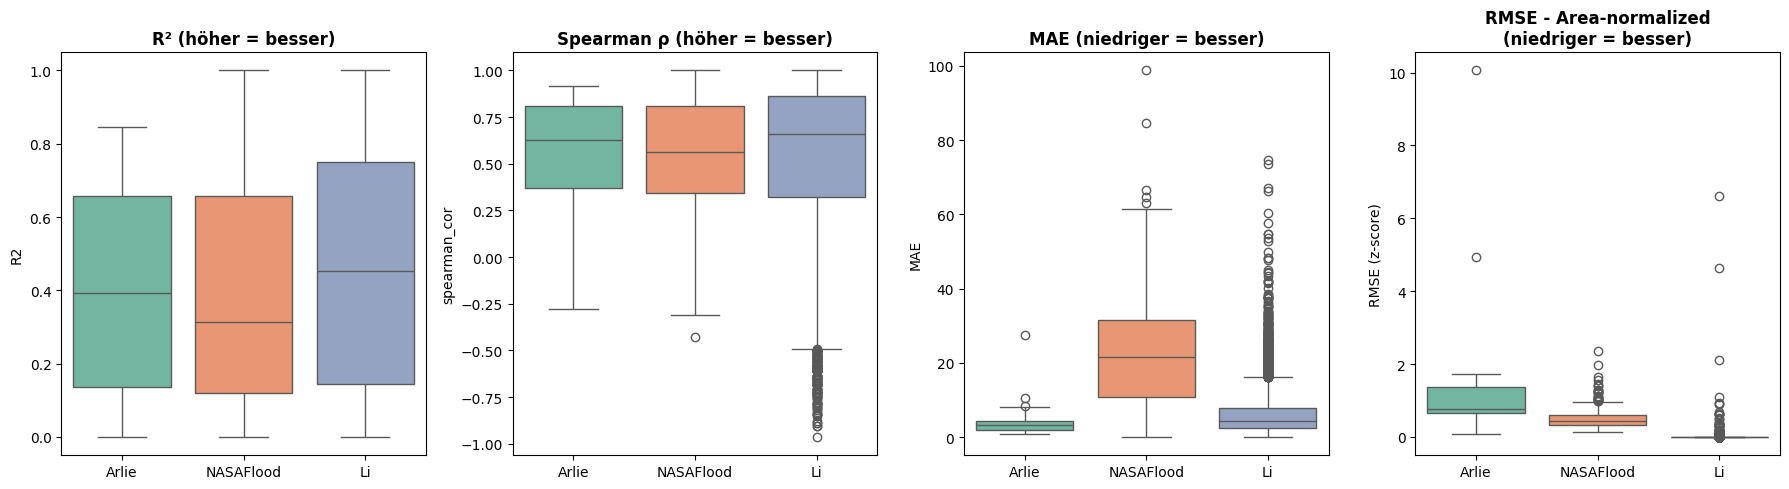

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Nur Area-perc für ersten 3 Plots
df_perc = stats_df_0[stats_df_0['value-type'] == 'Area-perc']
# Nur Area-normalized für RMSE
df_norm = stats_df_0[stats_df_0['value-type'] == 'Area-normalized']

# Erste 3 Plots: Area-perc
metrics_perc = ['R2', 'spearman_cor', 'MAE']
titles_perc = ['R² (höher = besser)', 'Spearman ρ (höher = besser)', 'MAE (niedriger = besser)']

for i, (metric, title) in enumerate(zip(metrics_perc, titles_perc)):
    sns.boxplot(data=df_perc, x='Dataset', y=metric, ax=axes[i], hue = "Dataset", palette='Set2')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric)

# 4. Plot: RMSE mit z-transformierten Daten
sns.boxplot(data=df_norm, x='Dataset', y='RMSE', ax=axes[3], hue = "Dataset", palette='Set2')
axes[3].set_title('0 RMSE - Area-normalized\n(niedriger = besser)', fontweight='bold')
axes[3].set_xlabel('')
axes[3].set_ylabel(' 0 RMSE (z-score)')

plt.tight_layout()
plt.show()

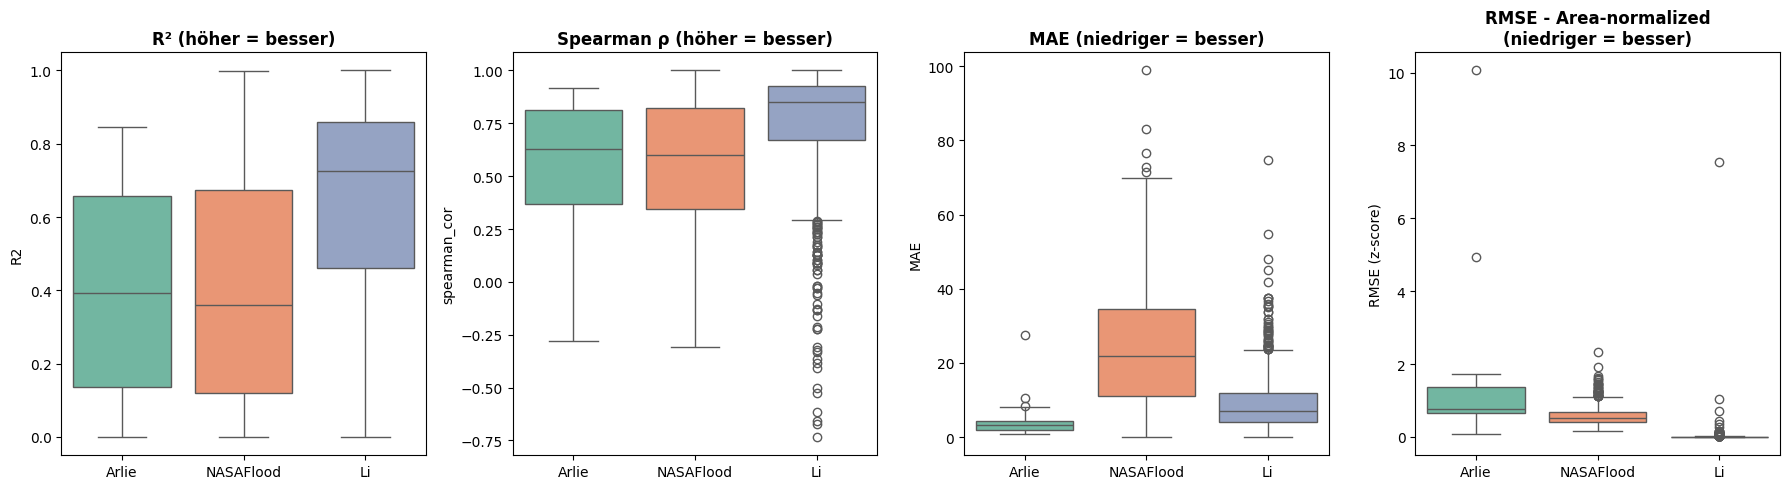

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Nur Area-perc für ersten 3 Plots
df_perc = stats_df_10[stats_df_10['value-type'] == 'Area-perc']
# Nur Area-normalized für RMSE
df_norm = stats_df_10[stats_df_10['value-type'] == 'Area-normalized']

# Erste 3 Plots: Area-perc
metrics_perc = ['R2', 'spearman_cor', 'MAE']
titles_perc = ['R² (höher = besser)', 'Spearman ρ (höher = besser)', 'MAE (niedriger = besser)']

for i, (metric, title) in enumerate(zip(metrics_perc, titles_perc)):
    sns.boxplot(data=df_perc, x='Dataset', y=metric, ax=axes[i], hue = "Dataset", palette='Set2')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric)

# 4. Plot: RMSE mit z-transformierten Daten
sns.boxplot(data=df_norm, x='Dataset', y='RMSE', ax=axes[3], hue = "Dataset", palette='Set2')
axes[3].set_title('RMSE - Area-normalized\n(niedriger = besser)', fontweight='bold')
axes[3].set_xlabel('')
axes[3].set_ylabel('RMSE (z-score)')

plt.tight_layout()
plt.show()

In [12]:
# helper to get ordered category list by median
def order_by_median(df, group_col, value_col, ascending=True):
    med = df.groupby(group_col)[value_col].median().sort_values(ascending=ascending)
    return med.index.tolist()



# Plot 1-3: Area-perc (sorted by median)
metrics = [
    ('R2', 'R²', True),                # higher is better -> sort ascending=False if you want best first
    ('spearman_cor', 'Spearman ρ', True),
    ('RMSE', 'RMSE - LSE in %', False)  # lower is better -> show lower medians first (ascending=True) or reverse as desired
]


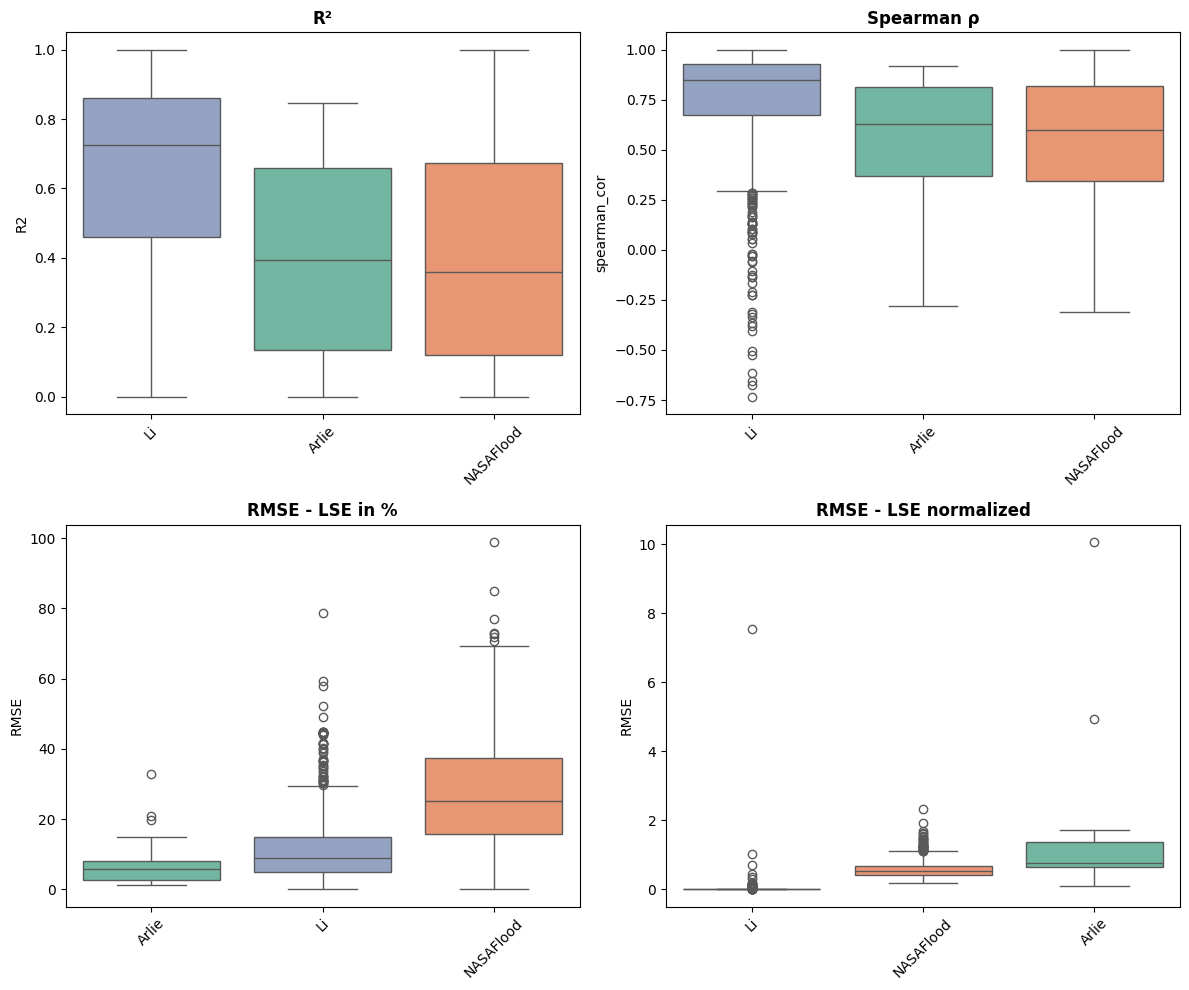

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

df_perc = stats_df_10[stats_df_10['value-type'] == 'Area-perc']
df_norm = stats_df_10[stats_df_10['value-type'] == 'Area-normalized']

for i, (metric, title, higher_better) in enumerate(metrics):
    # choose sort direction: if higher_better True -> show highest median on right by ascending=False
    order = order_by_median(df_perc, 'Dataset', metric, ascending=not higher_better)
    sns.boxplot(data=df_perc, x='Dataset', y=metric, ax=axes[i], order=order,  hue = "Dataset", palette='Set2')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Plot 4: Area-normalized RMSE (lower is better)
order_norm = order_by_median(df_norm, 'Dataset', 'RMSE', ascending=True)
sns.boxplot(data=df_norm, x='Dataset', y='RMSE', ax=axes[3], order=order_norm,  hue = "Dataset", palette='Set2')
axes[3].set_title('RMSE - LSE normalized', fontweight='bold')
axes[3].set_xlabel('')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

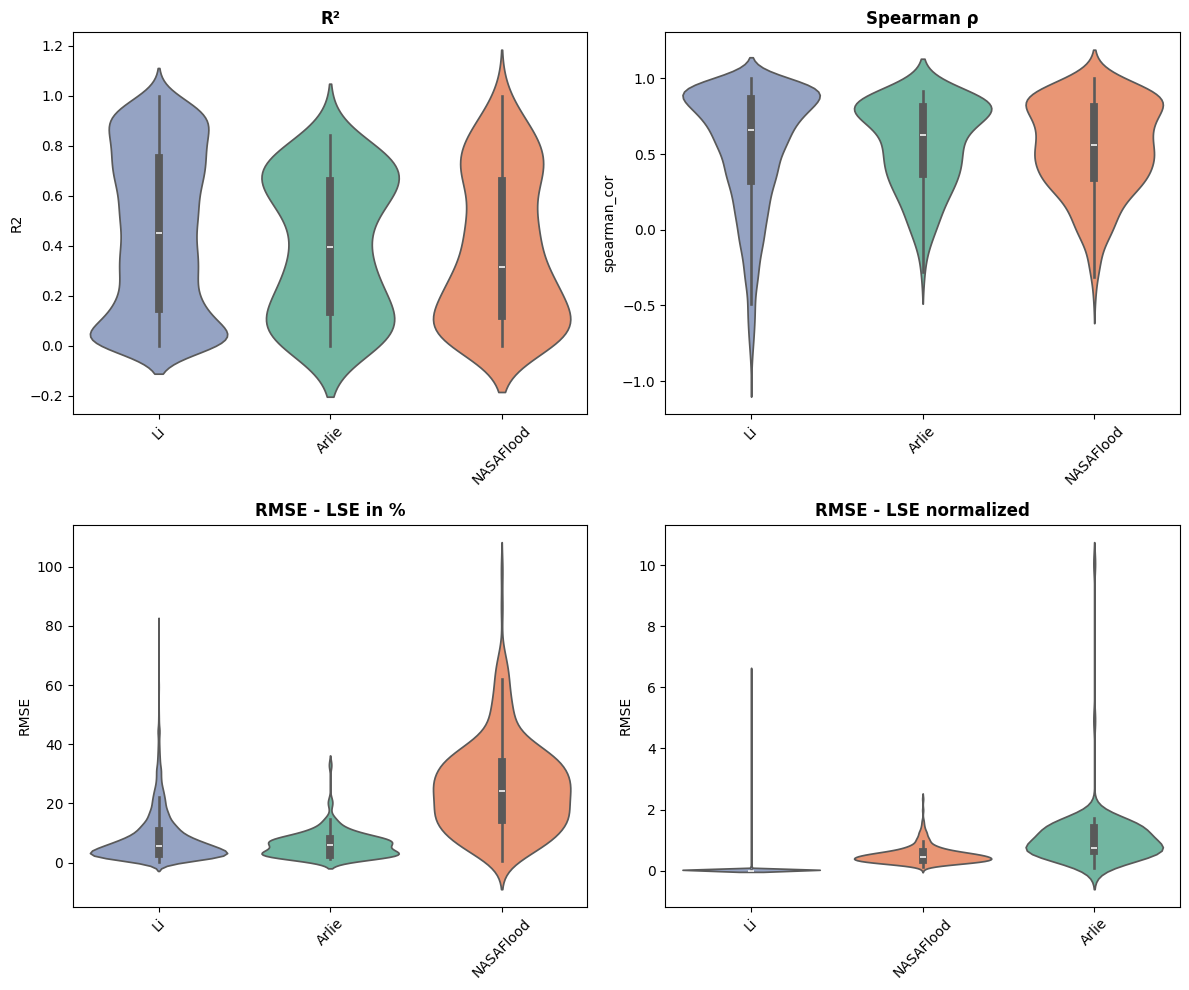

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

df_perc = stats_df_0[stats_df_0['value-type'] == 'Area-perc']
df_norm = stats_df_0[stats_df_0['value-type'] == 'Area-normalized']

for i, (metric, title, higher_better) in enumerate(metrics):
    # choose sort direction: if higher_better True -> show highest median on right by ascending=False
    order = order_by_median(df_perc, 'Dataset', metric, ascending=not higher_better)
    sns.violinplot(data=df_perc, x='Dataset', y=metric, ax=axes[i], order=order,  hue = "Dataset", palette='Set2')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Plot 4: Area-normalized RMSE (lower is better)
order_norm = order_by_median(df_norm, 'Dataset', 'RMSE', ascending=True)
sns.violinplot(data=df_norm, x='Dataset', y='RMSE', ax=axes[3], order=order_norm,  hue = "Dataset", palette='Set2')
axes[3].set_title('RMSE - LSE normalized', fontweight='bold')
axes[3].set_xlabel('')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()